In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, f1_score, recall_score,
    roc_auc_score, roc_curve, auc as sk_auc,
)
from params import RANDOM_STATE

plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          14,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     14,
    "xtick.labelsize":    14,
    "ytick.labelsize":    14,
    "legend.fontsize":    14,
    # legend title
    "legend.title_fontsize": 13,
    "legend.framealpha":  0.85,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.alpha":         0.35,
    "grid.linestyle":     "--",
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})


DA_COLORS = {
    "baseline": "#0072B2",
    "coral":    "#D55E00",
    "mmd":      "#E69F00",
}

SEEDS        = [RANDOM_STATE]
ARCHS        = ["autoencoder", "classifier"]
DA_VARIANTS  = ["baseline", "coral", "mmd"]
FEATURE_SETS = ["Handcrafted", "Latent", "Combined", "Combined_RFE"]
CLASSIFIERS  = ["RandomForest", "GradientBoosting", "SVM", "LogisticRegression"]
RESULTS_PATH = "results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

# classification results
frames = []
for arch in ARCHS:
    for da in DA_VARIANTS:
        for seed in SEEDS:
            p = os.path.join(RESULTS_PATH, f"double_ablation_metrics_{arch}_{da}_seed{seed}.csv")
            if os.path.exists(p):
                _df = pd.read_csv(p)
                _df["Arch"] = arch; _df["DA"] = da; _df["Seed"] = seed
                frames.append(_df)
            else:
                print(f"[SKIP] {p}")

df_ablation = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if not df_ablation.empty:
    df_ablation["Sensitivity"] = df_ablation["Recall"]
    df_ablation["Specificity"] = (2 * df_ablation["Balanced Acc"] - df_ablation["Recall"]).clip(0, 1)

# Domain classifier results
dom_frames = []
for seed in SEEDS:
    p = os.path.join(RESULTS_PATH, f"domain_classifier_results_seed{seed}.csv")
    if os.path.exists(p):
        _df = pd.read_csv(p); _df["Seed"] = seed
        dom_frames.append(_df)
    else:
        print(f"[SKIP] {p}")

df_domain = pd.concat(dom_frames, ignore_index=True) if dom_frames else pd.DataFrame()
print(f"Ablation : {len(df_ablation):,} rows  |  seeds: {SEEDS}")
print(f"Domain   : {len(df_domain):,} rows")


Ablation : 96 rows  |  seeds: [42]
Domain   : 72 rows


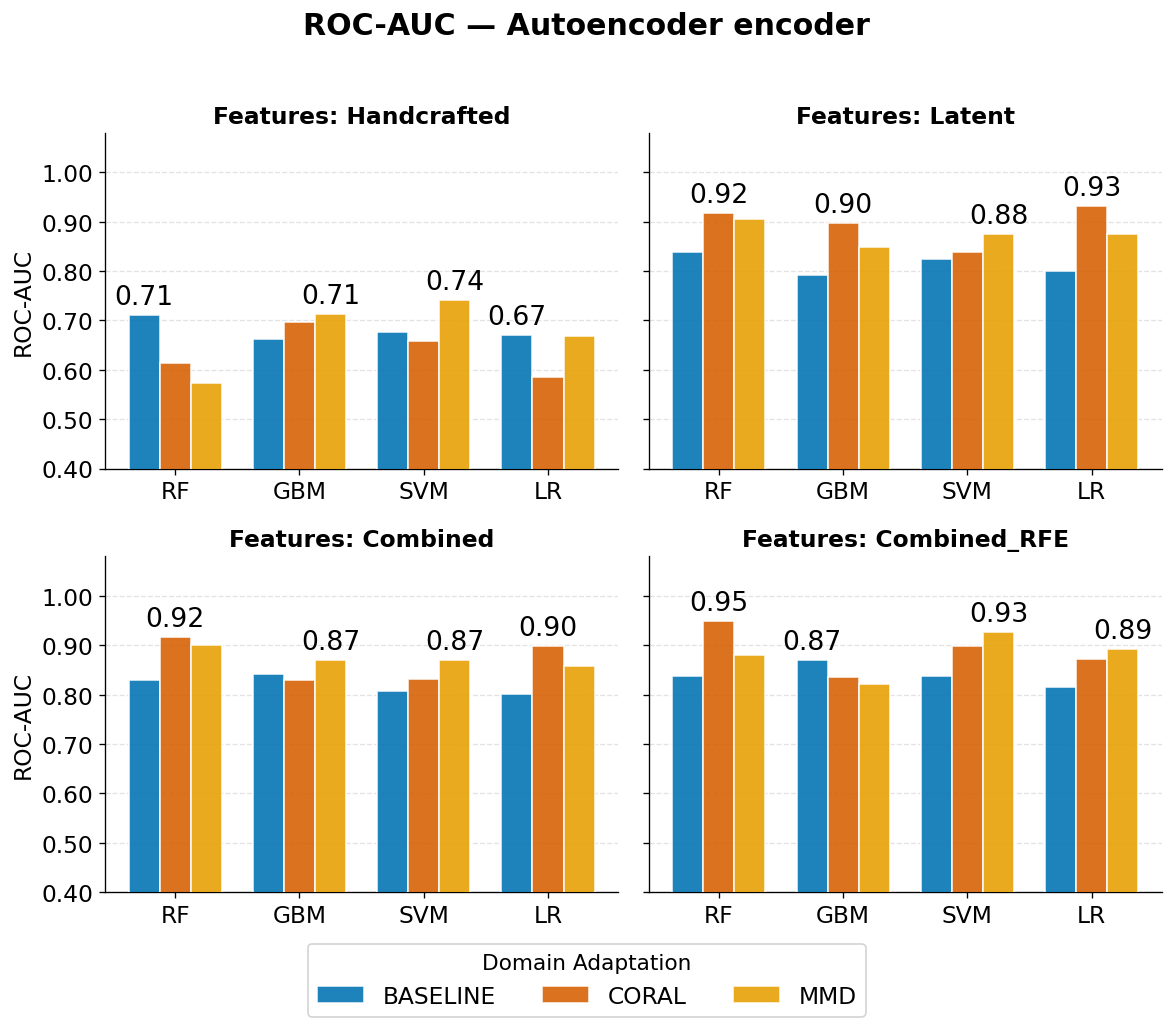

In [ ]:
ARCH   = "autoencoder"
METRIC = "ROC-AUC"

sub = df_ablation[df_ablation["Arch"] == ARCH]
agg = (sub.groupby(["DA", "Classifier", "Feature Set"])[METRIC]
         .agg(mean="mean", std="std").reset_index())

CLF_LABELS = {"RandomForest": "RF", "GradientBoosting": "GBM",
              "SVM": "SVM", "LogisticRegression": "LR"}
x, width = np.arange(len(CLASSIFIERS)), 0.25
offsets  = [-width, 0, width]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for i, feat in enumerate(FEATURE_SETS):
    ax = axes[i]

    max_da_idx = {
        clf: int(np.argmax([
            agg.loc[(agg["Feature Set"] == feat) & (agg["DA"] == da_var) & (agg["Classifier"] == clf), "mean"].fillna(0).values[0]
            if ((agg["Feature Set"] == feat) & (agg["DA"] == da_var) & (agg["Classifier"] == clf)).any() else 0.0
            for da_var in DA_VARIANTS
        ]))
        for clf in CLASSIFIERS
    }

    for j, da in enumerate(DA_VARIANTS):
        da_sub = (agg[(agg["Feature Set"] == feat) & (agg["DA"] == da)]
                  .set_index("Classifier").reindex(CLASSIFIERS))
        means = da_sub["mean"].fillna(0).values
        stds  = da_sub["std"].fillna(0).values

        bars = ax.bar(x + offsets[j], means, width, label=da.upper(),
                      color=DA_COLORS[da], edgecolor="white", alpha=0.88, zorder=3)

        for k, clf in enumerate(CLASSIFIERS):
            if j == max_da_idx[clf]:
                ax.text(x[k] + offsets[j], means[k] + 0.01, f"{means[k]:.2f}",
                        ha='center', va='bottom', fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels([CLF_LABELS[c] for c in CLASSIFIERS])
    ax.set_title(f"Features: {feat}")

    ax.set_ylim(0.40, 1.08)
    ax.set_ylabel(METRIC if i % 2 == 0 else "")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))


fig.suptitle("ROC-AUC — Autoencoder encoder\n", fontweight="bold", fontsize=18)
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Domain Adaptation", loc="lower center",
           bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.savefig(os.path.join(RESULTS_PATH, f"{ARCH}_roc_auc.pdf"), bbox_inches="tight", dpi=300)
plt.show()

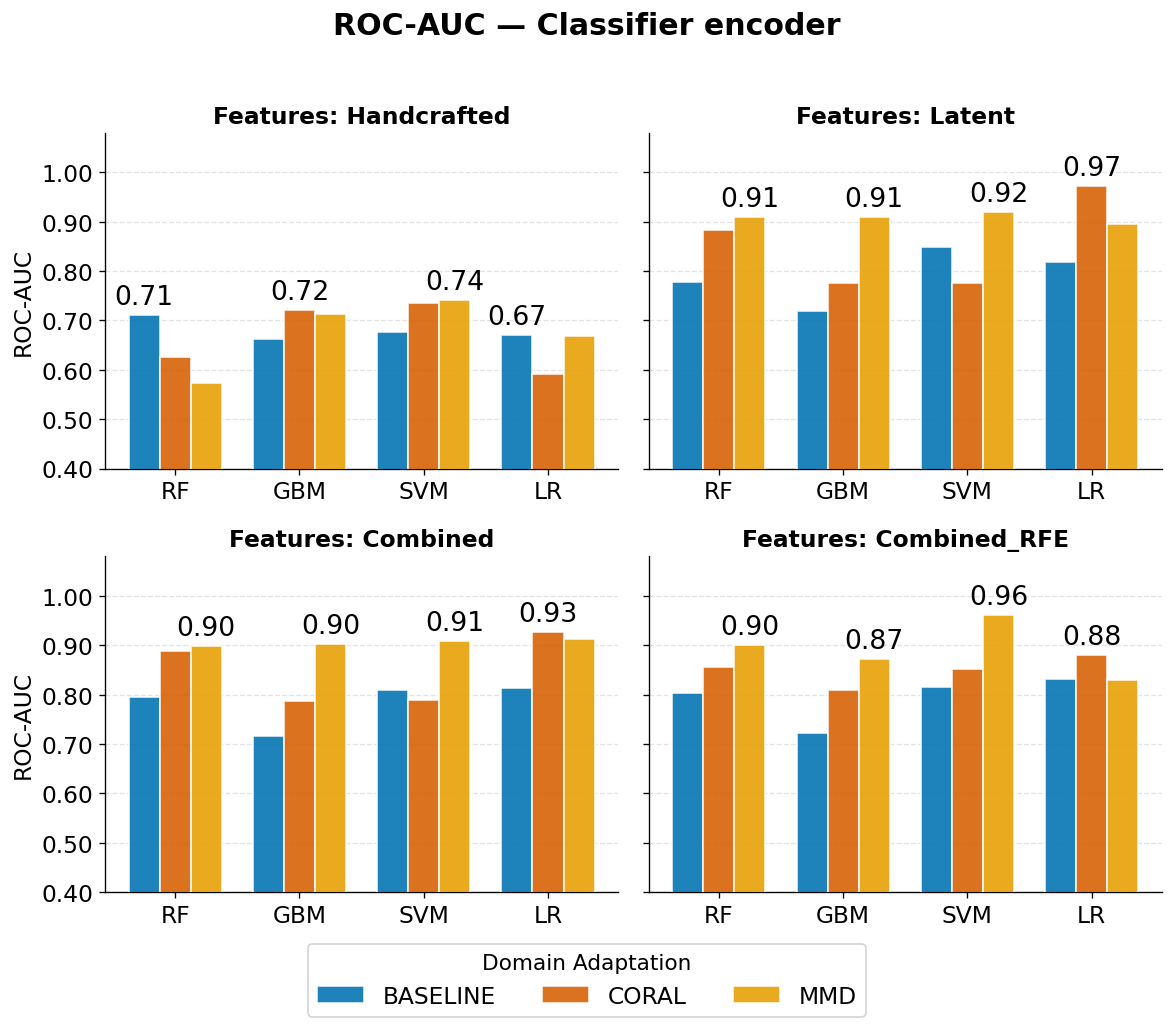

In [ ]:
ARCH   = "classifier"
METRIC = "ROC-AUC"

sub = df_ablation[df_ablation["Arch"] == ARCH]
agg = (sub.groupby(["DA", "Classifier", "Feature Set"])[METRIC]
         .agg(mean="mean", std="std").reset_index())

CLF_LABELS = {"RandomForest": "RF", "GradientBoosting": "GBM",
              "SVM": "SVM", "LogisticRegression": "LR"}
x, width = np.arange(len(CLASSIFIERS)), 0.25
offsets  = [-width, 0, width]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for i, feat in enumerate(FEATURE_SETS):
    ax = axes[i]
    max_da_idx = {
        clf: int(np.argmax([
            agg.loc[(agg["Feature Set"] == feat) & (agg["DA"] == da_var) & (agg["Classifier"] == clf), "mean"].fillna(0).values[0]
            if ((agg["Feature Set"] == feat) & (agg["DA"] == da_var) & (agg["Classifier"] == clf)).any() else 0.0
            for da_var in DA_VARIANTS
        ]))
        for clf in CLASSIFIERS
    }

    for j, da in enumerate(DA_VARIANTS):
        da_sub = (agg[(agg["Feature Set"] == feat) & (agg["DA"] == da)]
                  .set_index("Classifier").reindex(CLASSIFIERS))
        means = da_sub["mean"].fillna(0).values
        stds  = da_sub["std"].fillna(0).values

        bars = ax.bar(x + offsets[j], means, width, label=da.upper(),
                      color=DA_COLORS[da], edgecolor="white", alpha=0.88, zorder=3)

        for k, clf in enumerate(CLASSIFIERS):
            if j == max_da_idx[clf]:
                ax.text(x[k] + offsets[j], means[k] + 0.01, f"{means[k]:.2f}",
                        ha='center', va='bottom', fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels([CLF_LABELS[c] for c in CLASSIFIERS])
    ax.set_title(f"Features: {feat}")
    ax.set_ylim(0.40, 1.08)
    ax.set_ylabel(METRIC if i % 2 == 0 else "")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))


fig.suptitle("ROC-AUC — Classifier encoder\n", fontweight="bold", fontsize=18)
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Domain Adaptation", loc="lower center",
           bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.savefig(os.path.join(RESULTS_PATH, f"{ARCH}_roc_auc.pdf"), bbox_inches="tight", dpi=300)
plt.show()

Loaded: double_ablation_predictions_classifier_coral_seed42.xlsx
Loaded: double_ablation_predictions_autoencoder_coral_seed42.xlsx
Running bootstrap for: Classifier · Latent · LR · CORAL … done
Running bootstrap for: Autoencoder · Combined-RFE · RF · CORAL … done


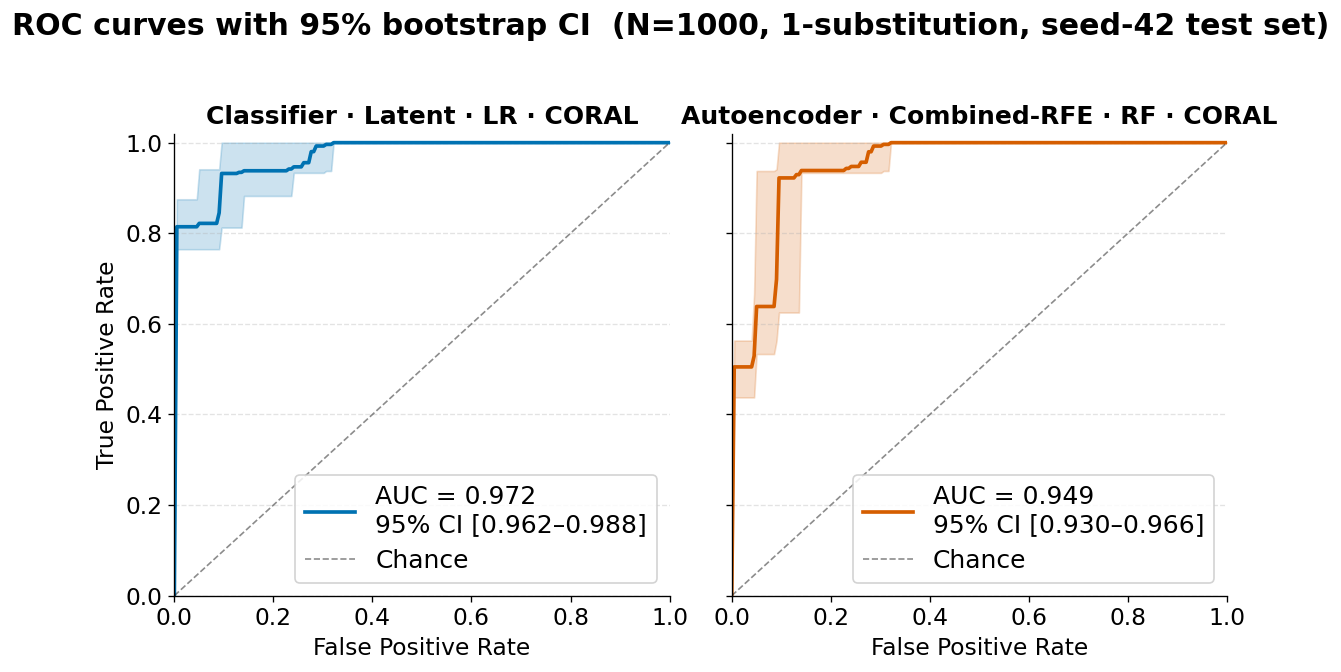


Configuration                                    Balanced Acc                Macro F1                    ROC-AUC                     Sensitivity                 Specificity               
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Classifier · Latent · LR · CORAL                 0.924 [0.900, 0.955]  0.920 [0.892, 0.947]  0.972 [0.962, 0.988]  0.938 [0.882, 1.000]  0.909 [0.864, 0.955]
Autoencoder · Combined-RFE · RF · CORAL          0.901 [0.878, 0.932]  0.894 [0.866, 0.921]  0.949 [0.930, 0.966]  0.939 [0.933, 1.000]  0.863 [0.818, 0.909]

[LaTeX] Saved: results/bootstrap_table_selected.tex  (preamble: \usepackage{booktabs})


In [ ]:
N_BOOTSTRAP = 1000
BOOT_SEED   = RANDOM_STATE

CONFIGS = [
    ("classifier",  "coral", "Latent",       "LogisticRegression",
     "Classifier · Latent · LR · CORAL"),
    ("autoencoder", "coral", "Combined_RFE",  "RandomForest",
     "Autoencoder · Combined-RFE · RF · CORAL"),
]
CFG_COLORS = ["#0072B2", "#D55E00"]

def _boot_roc(y_true, y_prob, n=N_BOOTSTRAP, seed=BOOT_SEED):
    rng      = np.random.default_rng(seed)
    n_samp   = len(y_true)
    fpr_grid = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    base_idx = np.arange(n_samp)
    for _ in range(n):
        idx       = base_idx.copy()
        pos       = rng.integers(0, n_samp)   # position to replace
        new_samp  = rng.integers(0, n_samp)   # replacement drawn with replacement
        idx[pos]  = new_samp
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        fpr, tpr, _ = roc_curve(yt, yp)
        row = np.interp(fpr_grid, fpr, tpr); row[0] = 0.0
        tprs.append(row); aucs.append(sk_auc(fpr, tpr))
    tprs = np.array(tprs)
    mean_tpr = tprs.mean(0); mean_tpr[-1] = 1.0
    return (fpr_grid, mean_tpr,
            np.percentile(tprs, 2.5,  axis=0),
            np.percentile(tprs, 97.5, axis=0),
            float(np.mean(aucs)),
            (float(np.percentile(aucs,  2.5)),
             float(np.percentile(aucs, 97.5))))


def _boot_metrics(y_true, y_pred, y_prob, n=N_BOOTSTRAP, seed=BOOT_SEED):
    rng      = np.random.default_rng(seed)
    n_samp   = len(y_true)
    store    = {m: [] for m in
                ["Balanced Acc", "Macro F1", "ROC-AUC", "Sensitivity", "Specificity"]}
    base_idx = np.arange(n_samp)
    for _ in range(n):
        idx       = base_idx.copy()
        pos       = rng.integers(0, n_samp)
        new_samp  = rng.integers(0, n_samp)
        idx[pos]  = new_samp
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        ba = balanced_accuracy_score(yt, yp)
        se = recall_score(yt, yp, zero_division=0)
        store["Balanced Acc"].append(ba)
        store["Macro F1"].append(f1_score(yt, yp, average="macro", zero_division=0))
        store["ROC-AUC"].append(roc_auc_score(yt, ypr))
        store["Sensitivity"].append(se)
        store["Specificity"].append(float(np.clip(2*ba - se, 0, 1)))
    return {m: {"mean":    float(np.mean(v)),
                "ci_low":  float(np.percentile(v,  2.5)),
                "ci_high": float(np.percentile(v, 97.5))}
            for m, v in store.items() if v}


# predictions
pred_cache = {}
for arch, da, *_ in CONFIGS:
    key = f"{arch}_{da}"
    if key in pred_cache:
        continue
    path = os.path.join(RESULTS_PATH,
           f"double_ablation_predictions_{arch}_{da}_seed{BOOT_SEED}.xlsx")
    if os.path.exists(path):
        pred_cache[key] = pd.read_excel(path)
        print(f"Loaded: {os.path.basename(path)}")
    else:
        print(f"[SKIP] {path}")


# roc auc
fig, axes_roc = plt.subplots(1, len(CONFIGS), figsize=(10, 5.5), sharey=True)

boot_results = {}

for ax, (arch, da, feat, clf, label), color in zip(axes_roc, CONFIGS, CFG_COLORS):
    df_p = pred_cache.get(f"{arch}_{da}")
    if df_p is None:
        ax.set_title(f"{label}\n[file missing]"); continue

    prob_col = f"prob_{clf}_{feat}"
    pred_col = f"y_pred_{clf}_{feat}"
    if prob_col not in df_p.columns:
        ax.set_title(f"{label}\n[column '{prob_col}' missing]"); continue

    y_true_a = df_p["y_true"].values.astype(int)
    y_pred_a = df_p[pred_col].values.astype(int)
    y_prob_a = df_p[prob_col].values

    print(f"Running bootstrap for: {label} …", end=" ", flush=True)
    fpr_g, tpr_m, tpr_lo, tpr_hi, auc_m, auc_ci = _boot_roc(y_true_a, y_prob_a)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        bm = _boot_metrics(y_true_a, y_pred_a, y_prob_a)
    boot_results[(arch, da, feat, clf)] = bm
    print("done")

    ax.plot(fpr_g, tpr_m, color=color, lw=2.2,
            label=f"AUC = {auc_m:.3f}\n95% CI [{auc_ci[0]:.3f}–{auc_ci[1]:.3f}]")
    ax.fill_between(fpr_g, tpr_lo, tpr_hi, alpha=0.20, color=color)
    ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.45, label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate" if ax is axes_roc[0] else "")
    ax.set_title(label, fontsize=15)
    ax.set_xlim(0,1); ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right", fontsize=15)

fig.suptitle(
    f"ROC curves with 95% bootstrap CI  (N={N_BOOTSTRAP}, 1-substitution, seed-{BOOT_SEED} test set)",
    y=1.02, fontweight="bold", fontsize=18
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "roc_bootstrap_ci_selected.pdf"))
plt.show()


METRIC_NAMES = ["Balanced Acc", "Macro F1", "ROC-AUC", "Sensitivity", "Specificity"]
_M_LBL = {"Balanced Acc": r"Bal.\ Acc.", "Macro F1": r"Macro F1",
           "ROC-AUC": r"AUC", "Sensitivity": r"Sens.", "Specificity": r"Spec."}

header = f"{'Configuration':<47}" + "".join(f"  {m:<26}" for m in METRIC_NAMES)
print(f"\n{header}")
print("─" * len(header))
for (arch, da, feat, clf, label), _ in zip(CONFIGS, CFG_COLORS):
    bm = boot_results.get((arch, da, feat, clf))
    if bm is None: print(f"{label:<47}  [missing]"); continue
    row = "  ".join(
        f"{bm[m]['mean']:.3f} [{bm[m]['ci_low']:.3f}, {bm[m]['ci_high']:.3f}]"
        for m in METRIC_NAMES)
    print(f"{label:<47}  {row}")

n_mc  = len(METRIC_NAMES)
hdr_l = (r"\textbf{Configuration} & "
         + " & ".join(f"\\textbf{{{_M_LBL[m]}}}" for m in METRIC_NAMES) + r" \\")
lines = [
    r"\begin{table}[ht]", r"\centering",
    r"\caption{Bootstrap 95\,\% CI for selected configurations "
    r"(N\,=\," + str(N_BOOTSTRAP) + r" iterations, 1-substitution, seed-" + str(BOOT_SEED) + r" test set).}",
    r"\label{tab:boot_selected}",
    r"\begin{tabular}{@{}l" + "r"*n_mc + r"@{}}",
    r"\toprule", hdr_l, r"\midrule",
]
for (arch, da, feat, clf, label), _ in zip(CONFIGS, CFG_COLORS):
    bm = boot_results.get((arch, da, feat, clf))
    if bm is None: continue
    mcells = " & ".join(
        f"${bm[m]['mean']:.3f}$ [{bm[m]['ci_low']:.3f}, {bm[m]['ci_high']:.3f}]"
        for m in METRIC_NAMES)
    lines.append(f"{label} & {mcells} \\\\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

out = os.path.join(RESULTS_PATH, "bootstrap_table_selected.tex")
with open(out, "w", encoding="utf-8") as f: f.write("\n".join(lines))
print(f"\n[LaTeX] Saved: {out}  (preamble: \\usepackage{{booktabs}})")


Running PR bootstrap for: Classifier · Latent · LR · CORAL … done
Running PR bootstrap for: Autoencoder · Combined-RFE · RF · CORAL … done


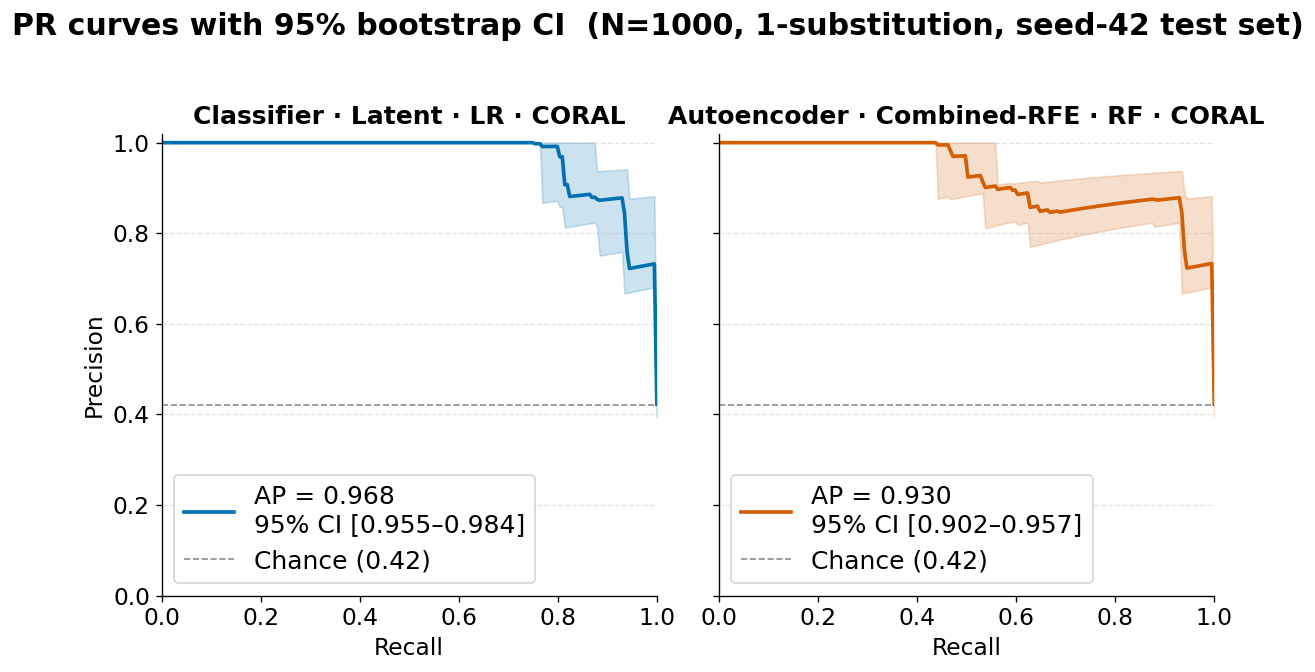


Average Precision (AP) with 95% bootstrap CI:
────────────────────────────────────────────────────────────────────────────────
Classifier · Latent · LR · CORAL                 AP = 0.968 [0.955, 0.984]
Autoencoder · Combined-RFE · RF · CORAL          AP = 0.930 [0.902, 0.957]

[LaTeX] Saved: results/bootstrap_pr_table_selected.tex  (preamble: \usepackage{booktabs})


In [ ]:

from sklearn.metrics import precision_recall_curve, average_precision_score


def _boot_pr(y_true, y_prob, n=N_BOOTSTRAP, seed=BOOT_SEED):
    rng      = np.random.default_rng(seed)
    n_samp   = len(y_true)
    rec_grid = np.linspace(0, 1, 200)
    precisions, aps = [], []
    base_idx = np.arange(n_samp)
    for _ in range(n):
        idx      = base_idx.copy()
        pos      = rng.integers(0, n_samp)   # position to replace
        new_samp = rng.integers(0, n_samp)   # replacement drawn with replacement
        idx[pos] = new_samp
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(yt, yp)
        # recall is decreasing; flip for np.interp (needs increasing xp)
        row = np.interp(rec_grid, rec[::-1], prec[::-1])
        precisions.append(row)
        aps.append(average_precision_score(yt, yp))
    precisions = np.array(precisions)
    mean_prec  = precisions.mean(0)
    return (rec_grid, mean_prec,
            np.percentile(precisions,  2.5, axis=0),
            np.percentile(precisions, 97.5, axis=0),
            float(np.mean(aps)),
            (float(np.percentile(aps,  2.5)),
             float(np.percentile(aps, 97.5))))


# pr
fig, axes_pr = plt.subplots(1, len(CONFIGS), figsize=(10, 5.5), sharey=True)

pr_boot_results = {}

for ax, (arch, da, feat, clf, label), color in zip(axes_pr, CONFIGS, CFG_COLORS):
    df_p = pred_cache.get(f"{arch}_{da}")
    if df_p is None:
        ax.set_title(f"{label}\n[file missing]"); continue

    prob_col = f"prob_{clf}_{feat}"
    if prob_col not in df_p.columns:
        ax.set_title(f"{label}\n[column '{prob_col}' missing]"); continue

    y_true_a = df_p["y_true"].values.astype(int)
    y_prob_a = df_p[prob_col].values
    pos_ratio = float(y_true_a.mean())

    print(f"Running PR bootstrap for: {label} …", end=" ", flush=True)
    rec_g, prec_m, prec_lo, prec_hi, ap_m, ap_ci = _boot_pr(y_true_a, y_prob_a)
    pr_boot_results[(arch, da, feat, clf)] = {
        "AP": {"mean": ap_m, "ci_low": ap_ci[0], "ci_high": ap_ci[1]}
    }
    print("done")

    ax.plot(rec_g, prec_m, color=color, lw=2.2,
            label=f"AP = {ap_m:.3f}\n95% CI [{ap_ci[0]:.3f}–{ap_ci[1]:.3f}]")
    ax.fill_between(rec_g, prec_lo, prec_hi, alpha=0.20, color=color)
    ax.axhline(pos_ratio, color="k", linestyle="--", lw=1, alpha=0.45,
               label=f"Chance ({pos_ratio:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision" if ax is axes_pr[0] else "")
    ax.set_title(label, fontsize=15)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left", fontsize=15)

fig.suptitle(
    f"PR curves with 95% bootstrap CI  (N={N_BOOTSTRAP}, 1-substitution, seed-{BOOT_SEED} test set)",
    y=1.02, fontweight="bold", fontsize=18
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "pr_bootstrap_ci_selected.pdf"))
plt.show()


print("\nAverage Precision (AP) with 95% bootstrap CI:")
print("─" * 80)
for (arch, da, feat, clf, label), _ in zip(CONFIGS, CFG_COLORS):
    res = pr_boot_results.get((arch, da, feat, clf))
    if res is None:
        print(f"{label:<47}  [missing]"); continue
    ap = res["AP"]
    print(f"{label:<47}  AP = {ap['mean']:.3f} [{ap['ci_low']:.3f}, {ap['ci_high']:.3f}]")

lines_pr = [
    r"\begin{table}[ht]", r"\centering",
    r"\caption{Bootstrap 95\,\% CI for Average Precision of selected configurations "
    r"(N\,=\," + str(N_BOOTSTRAP) + r" iterations, 1-substitution, seed-" + str(BOOT_SEED) + r" test set).}",
    r"\label{tab:boot_pr_selected}",
    r"\begin{tabular}{@{}lr@{}}",
    r"\toprule",
    r"\textbf{Configuration} & \textbf{AP mean [95\,\% CI]} \\",
    r"\midrule",
]
for (arch, da, feat, clf, label), _ in zip(CONFIGS, CFG_COLORS):
    res = pr_boot_results.get((arch, da, feat, clf))
    if res is None:
        continue
    ap = res["AP"]
    lines_pr.append(
        f"{label} & ${ap['mean']:.3f}$ [{ap['ci_low']:.3f}, {ap['ci_high']:.3f}] \\\\"
    )
lines_pr += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

out_pr = os.path.join(RESULTS_PATH, "bootstrap_pr_table_selected.tex")
with open(out_pr, "w", encoding="utf-8") as f:
    f.write("\n".join(lines_pr))
print(f"\n[LaTeX] Saved: {out_pr}  (preamble: \\usepackage{{booktabs}})")


Dataset axis used for all architectures: ['kiel', 'omnia_park', 'wearpd']

=== Architecture: CLASSIFIER_BASELINE (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. SVM su Latent -> ROC-AUC: 0.8494
  2. LogisticRegression su Combined_RFE -> ROC-AUC: 0.8324
  3. LogisticRegression su Latent -> ROC-AUC: 0.8182
  4. SVM su Combined_RFE -> ROC-AUC: 0.8153


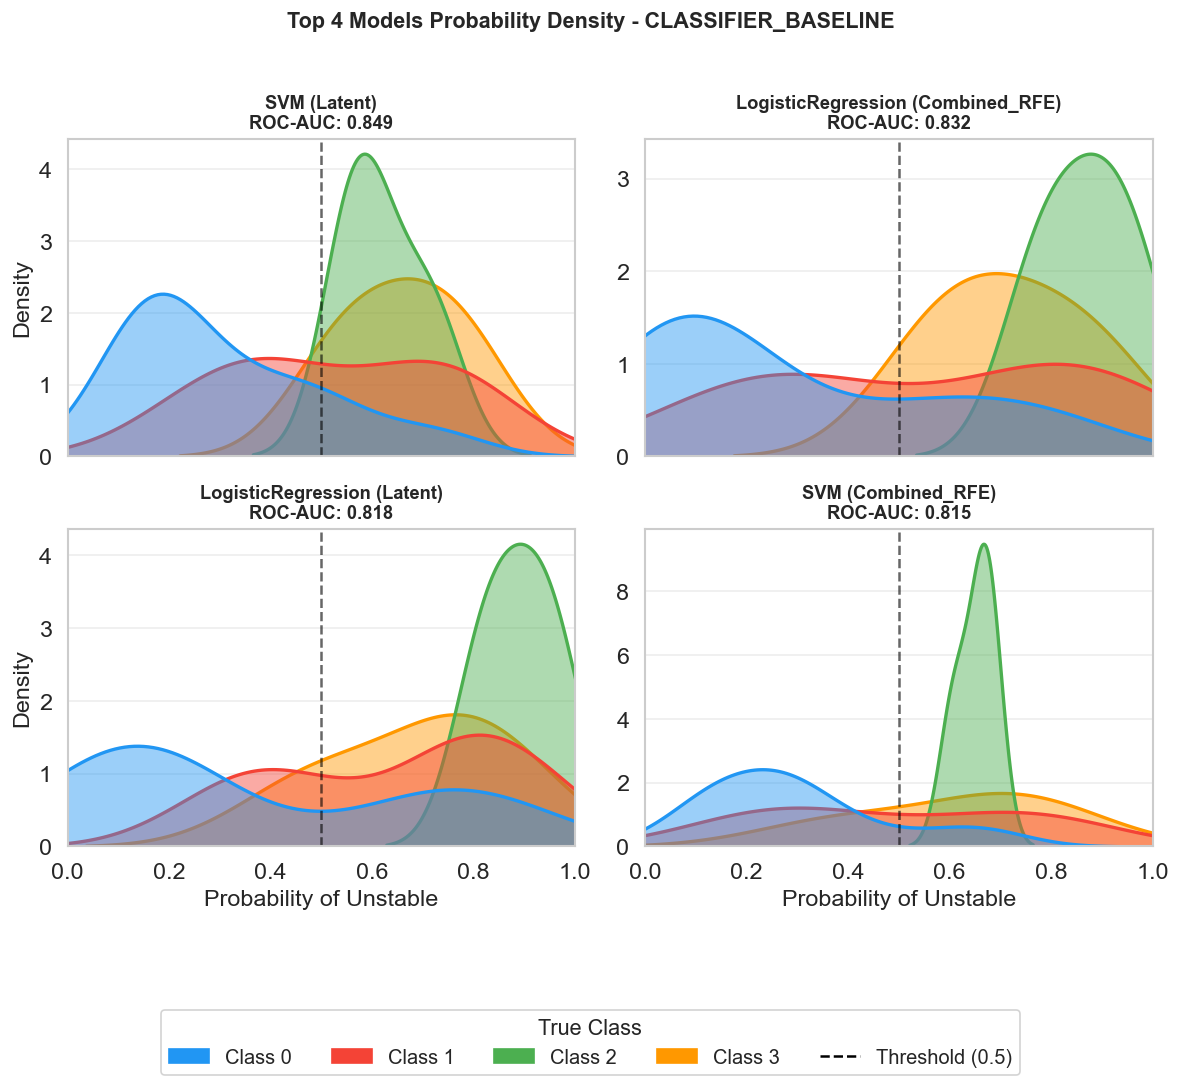

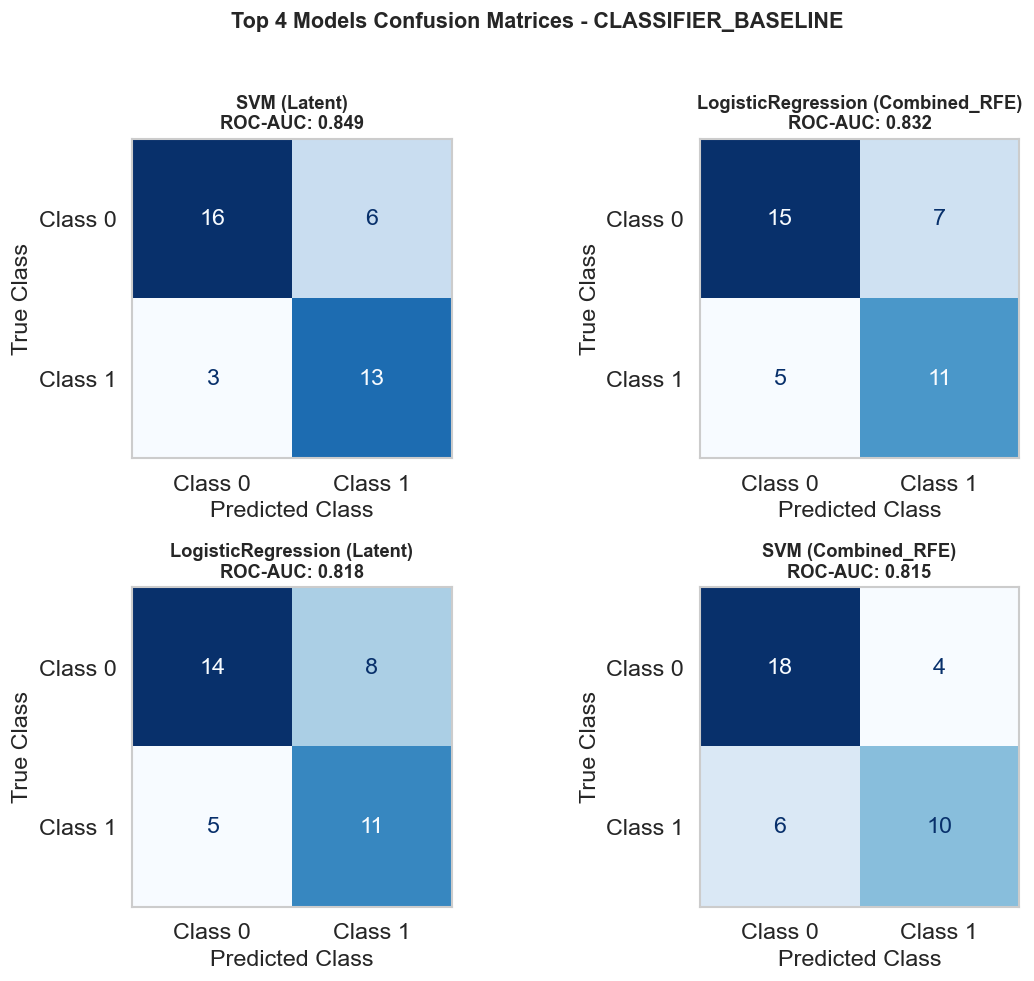


=== Architecture: AUTOENCODER_BASELINE (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. GradientBoosting su Combined_RFE -> ROC-AUC: 0.8693
  2. GradientBoosting su Combined -> ROC-AUC: 0.8409
  3. RandomForest su Latent -> ROC-AUC: 0.8381
  4. RandomForest su Combined_RFE -> ROC-AUC: 0.8381


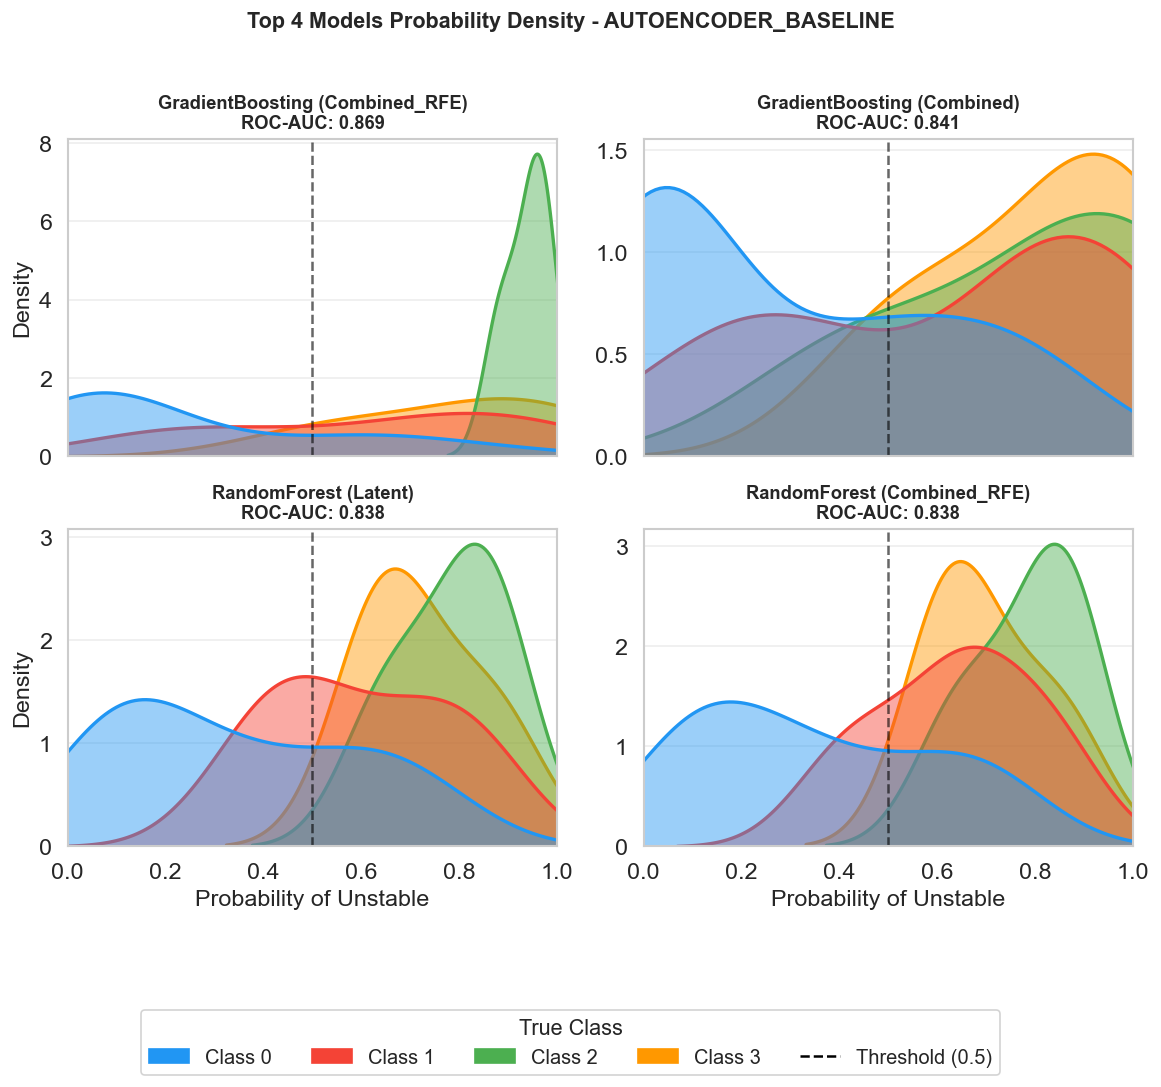

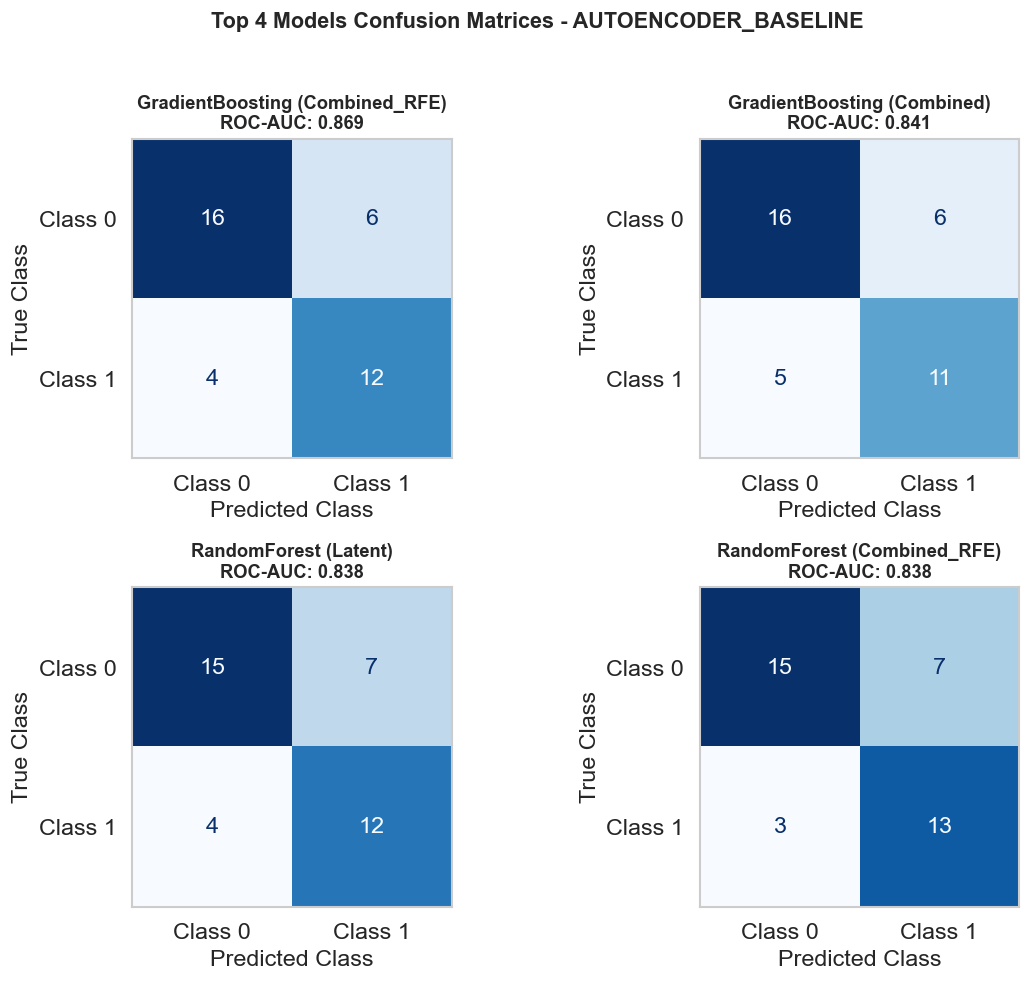


=== Architecture: CLASSIFIER_MMD (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. SVM su Combined_RFE -> ROC-AUC: 0.9602
  2. SVM su Latent -> ROC-AUC: 0.9205
  3. LogisticRegression su Combined -> ROC-AUC: 0.9119
  4. RandomForest su Latent -> ROC-AUC: 0.9091


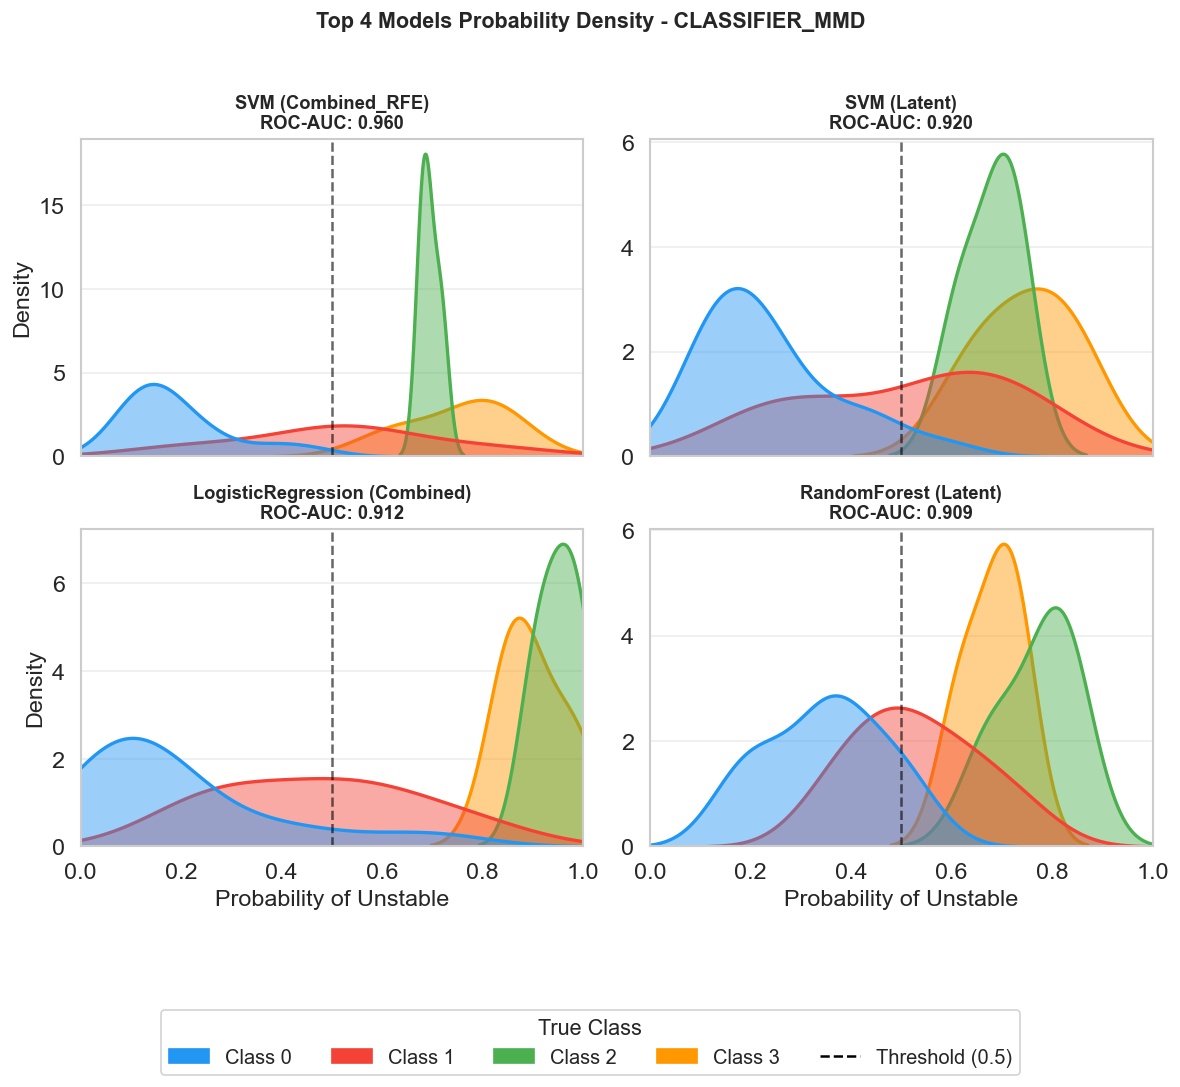

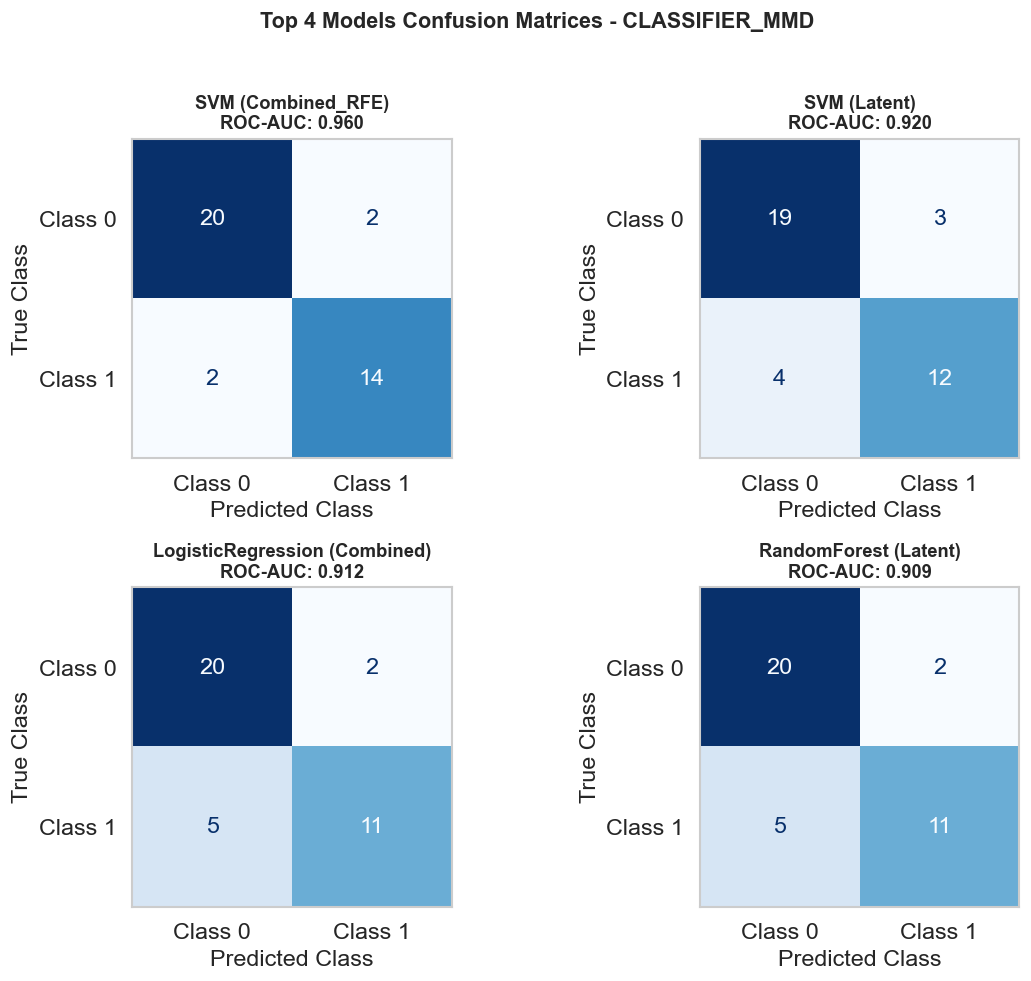


=== Architecture: AUTOENCODER_MMD (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. SVM su Combined_RFE -> ROC-AUC: 0.9261
  2. RandomForest su Latent -> ROC-AUC: 0.9062
  3. RandomForest su Combined -> ROC-AUC: 0.9006
  4. LogisticRegression su Combined_RFE -> ROC-AUC: 0.8920


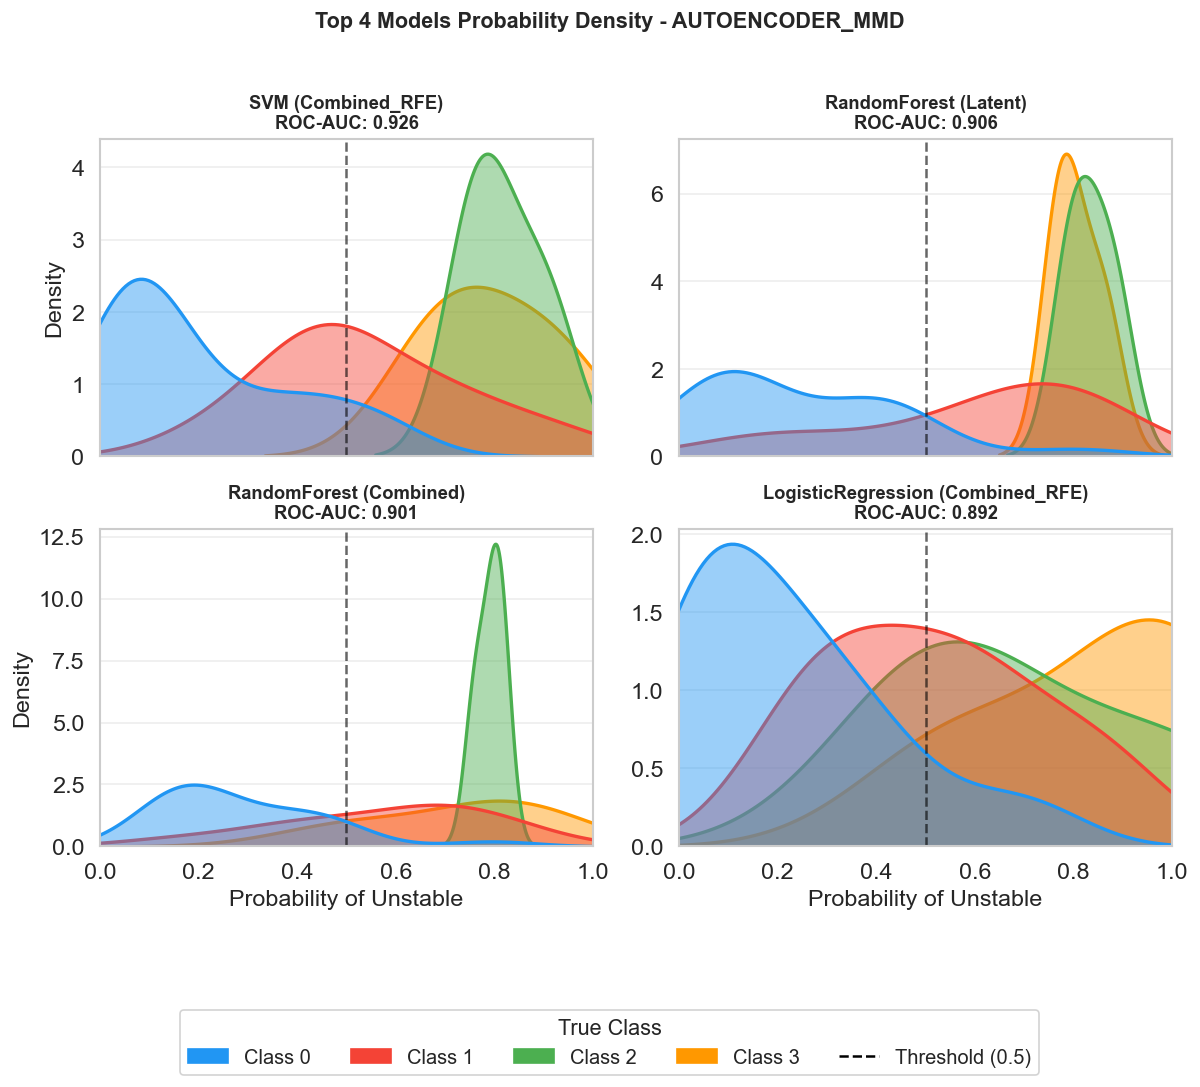

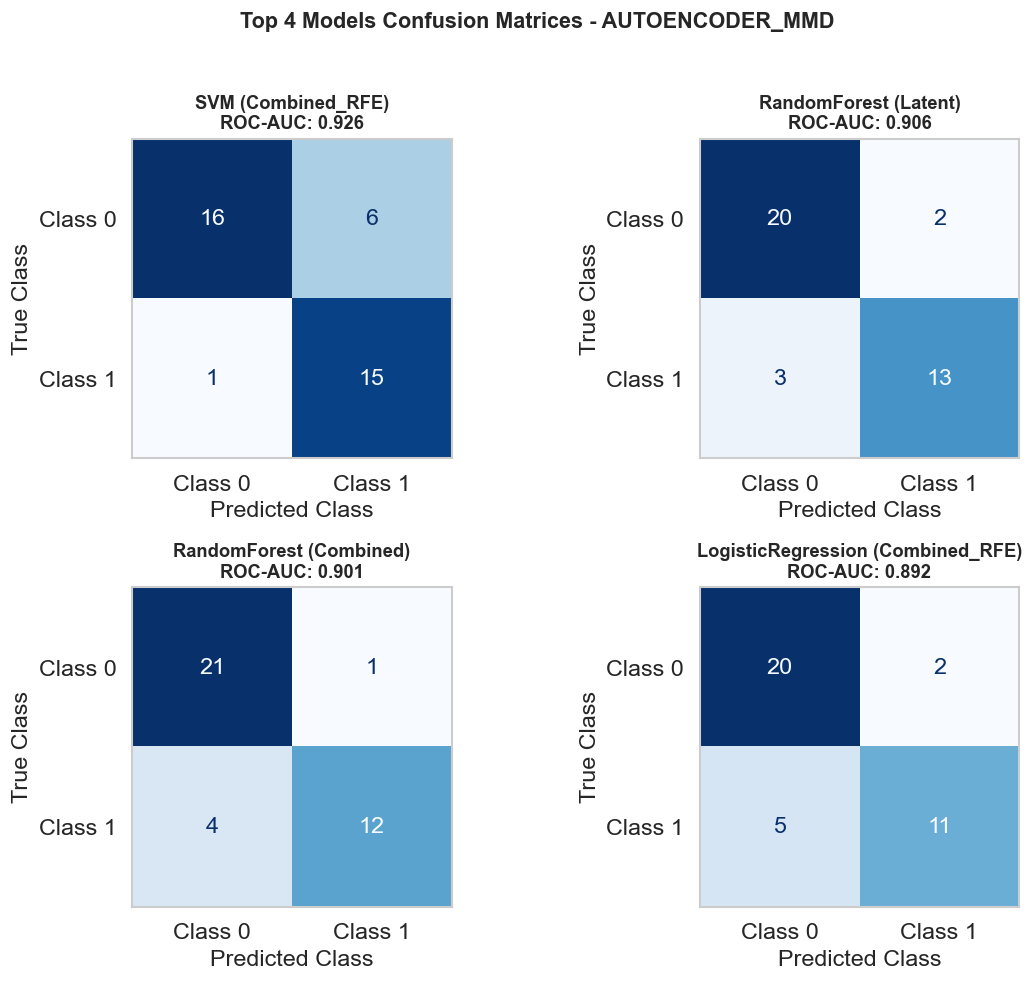


=== Architecture: CLASSIFIER_CORAL (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. LogisticRegression su Latent -> ROC-AUC: 0.9716
  2. LogisticRegression su Combined -> ROC-AUC: 0.9261
  3. RandomForest su Combined -> ROC-AUC: 0.8892
  4. RandomForest su Latent -> ROC-AUC: 0.8835


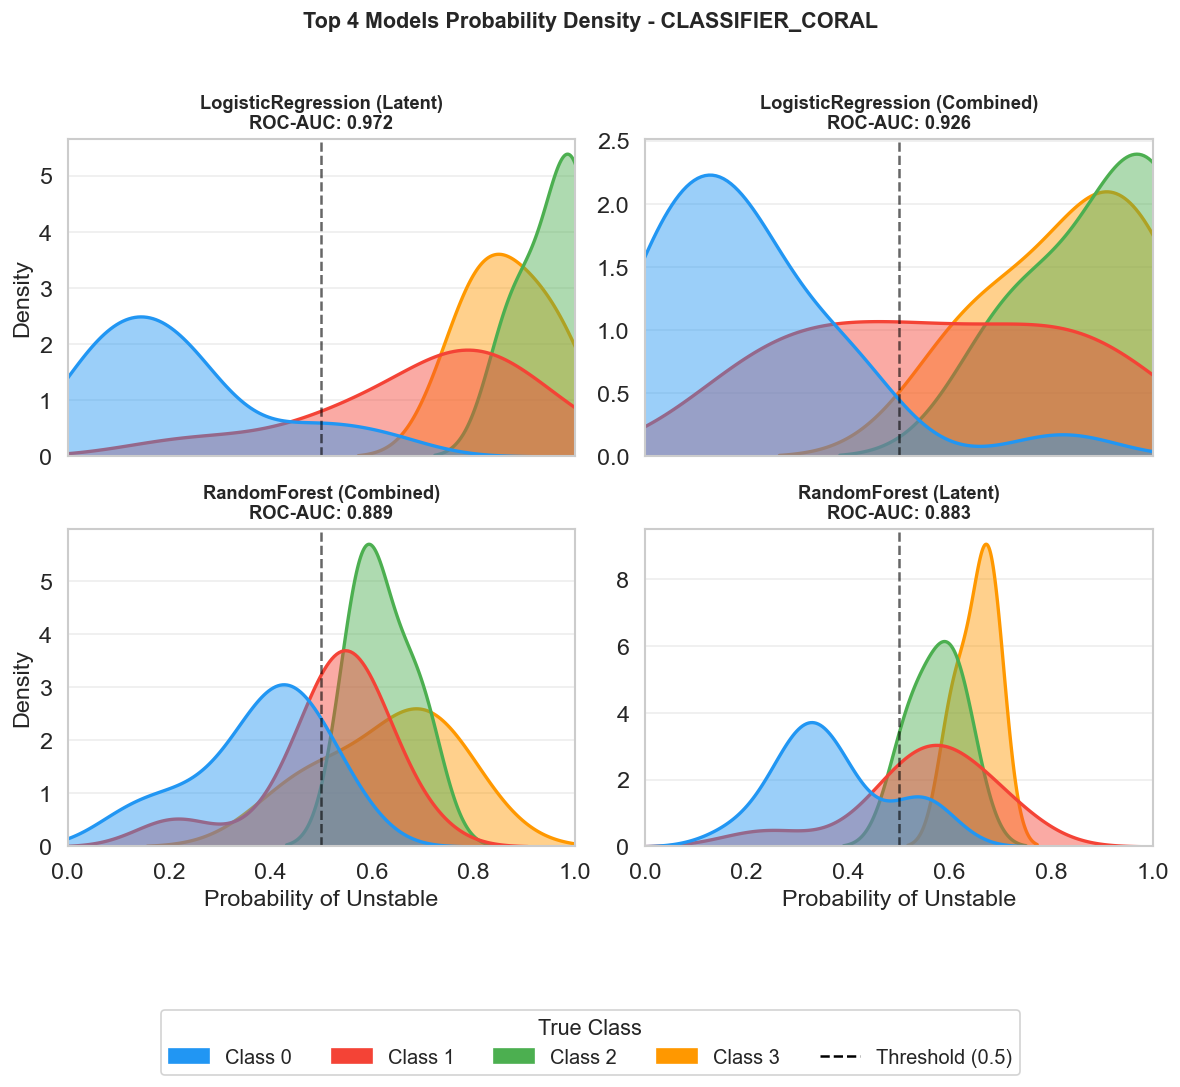

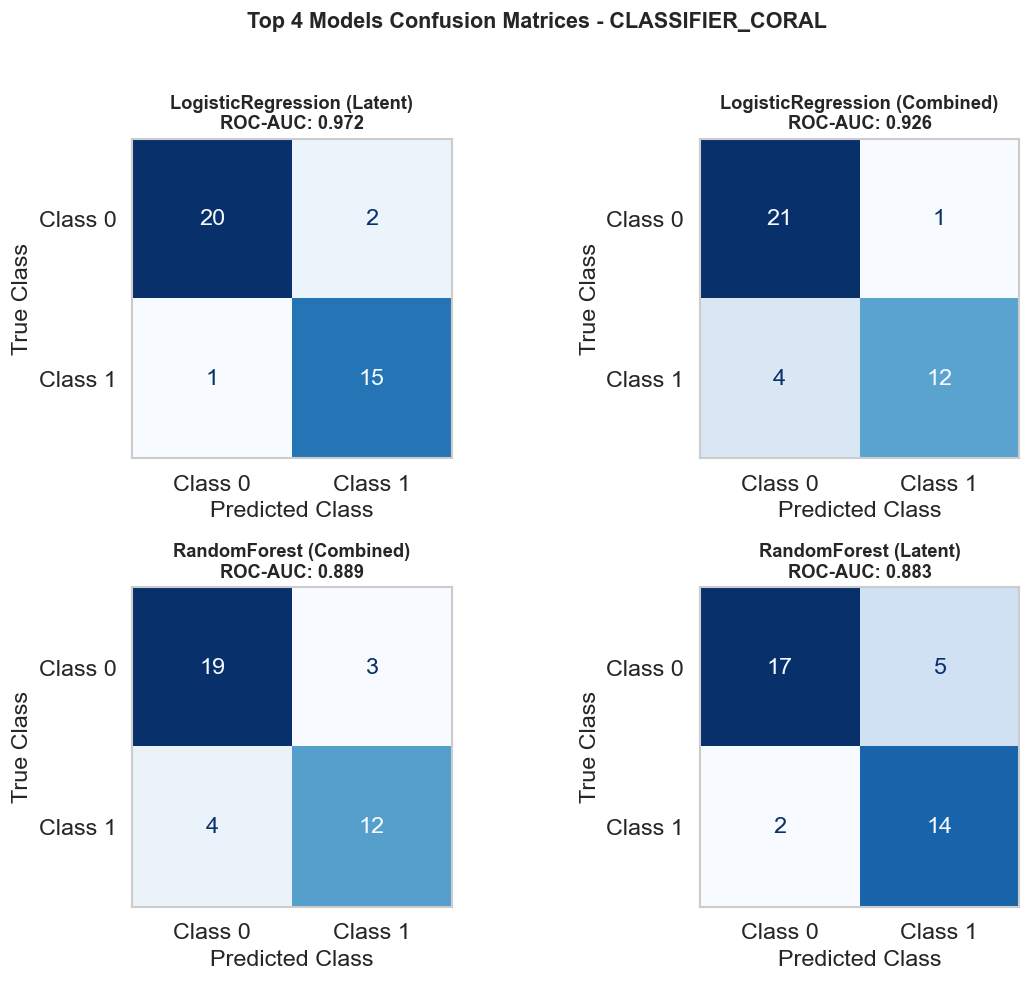


=== Architecture: AUTOENCODER_CORAL (TOP 4 PERFORMERS BY ROC-AUC) ===
  1. RandomForest su Combined_RFE -> ROC-AUC: 0.9489
  2. LogisticRegression su Latent -> ROC-AUC: 0.9318
  3. RandomForest su Latent -> ROC-AUC: 0.9176
  4. RandomForest su Combined -> ROC-AUC: 0.9176


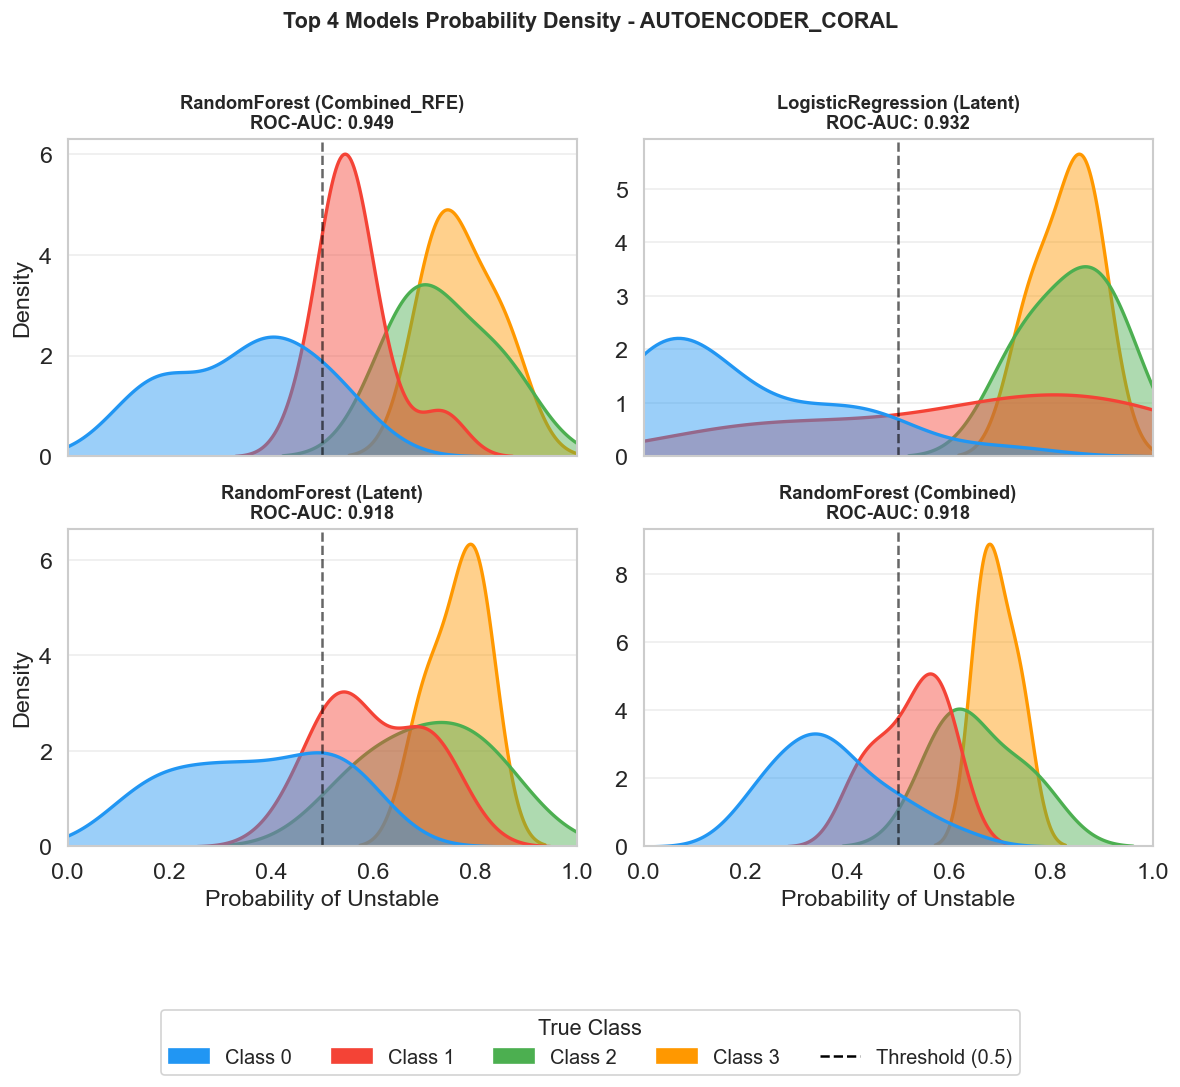

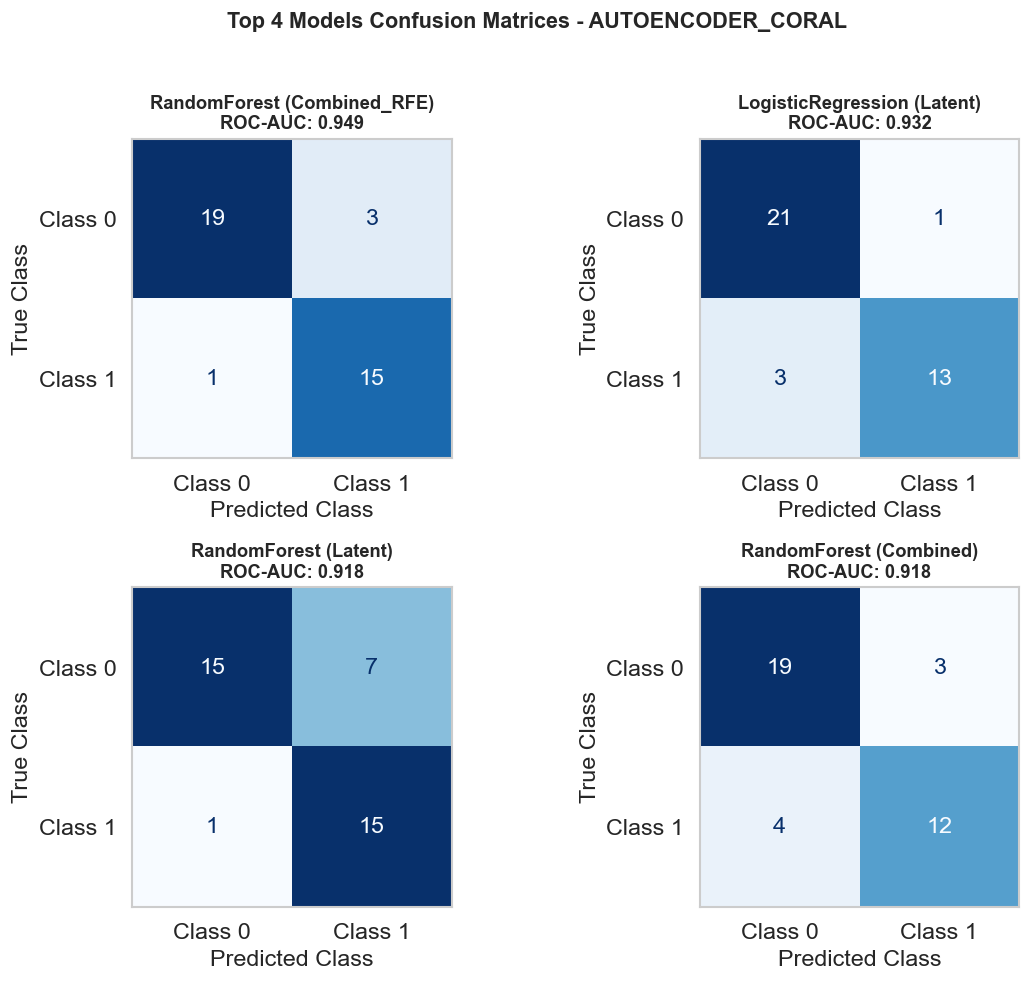

In [ ]:
modes = [
    "classifier_baseline", "autoencoder_baseline", 
    "classifier_mmd", "autoencoder_mmd", 
    "classifier_coral", "autoencoder_coral"
]
RESULTS_PATH = "results/"

TOP_N = 4       
METRIC = "ROC-AUC" 
class_colors = {0: "#2196F3", 1: "#F44336", 2: "#4CAF50", 3: "#FF9800"} 
class_labels = {0: "Class 0", 1: "Class 1", 2: "Class 2", 3: "Class 3"}
mode_to_df = {}
mode_to_metrics = {}
all_datasets = set()

for mode in modes:
    pred_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{mode}_seed42.xlsx")
    metrics_path = os.path.join(RESULTS_PATH, f"double_ablation_metrics_{mode}_seed42.csv")
    
    # Fallback nel caso in cui i file siano direttamente nella cartella di lavoro corrente
    if not os.path.exists(pred_path): pred_path = f"double_ablation_predictions_{mode}_seed42.xlsx"
    if not os.path.exists(metrics_path): metrics_path = f"double_ablation_metrics_{mode}_seed42.csv"

    if not os.path.exists(pred_path) or not os.path.exists(metrics_path):
        print(f"[SKIP] File predizioni o metriche mancanti per la modalità '{mode}'")
        continue

    df_mode = pd.read_excel(pred_path)
    df_metrics = pd.read_csv(metrics_path)
    
    mode_to_df[mode] = df_mode
    mode_to_metrics[mode] = df_metrics
    if "dataset" in df_mode.columns:
        all_datasets.update(df_mode["dataset"].dropna().astype(str).unique())

if not mode_to_df:
    raise FileNotFoundError("Nessun set completo di file predizioni/metriche trovato.")

print("Dataset axis used for all architectures:", sorted(all_datasets))
sns.set_theme(style="whitegrid")


for mode, df in mode_to_df.items():

    metrics_df = mode_to_metrics[mode].copy()
    metrics_df = metrics_df.sort_values(by=METRIC, ascending=False).head(TOP_N)
    top_models = list(zip(metrics_df["Classifier"], metrics_df["Feature Set"], metrics_df[METRIC]))
    
    print(f"\n{'='*75}\n=== Architecture: {mode.upper()} (TOP {TOP_N} PERFORMERS BY {METRIC}) ===\n{'='*75}")
    for idx, (clf, feat, score) in enumerate(top_models):
        print(f"  {idx+1}. {clf} su {feat} -> {METRIC}: {score:.4f}")


    hue_col = "y_true_4cls" if "y_true_4cls" in df.columns else "y_true"
    unique_classes = sorted(df[hue_col].dropna().astype(int).unique())
    palette = {c: class_colors.get(c, "gray") for c in unique_classes}

    fig_kde, axes_kde = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8))
    
    axes_kde = axes_kde.flatten()
    axes_cm = axes_cm.flatten()

    fig_kde.suptitle(f"Top {TOP_N} Models Probability Density - {mode.upper()}", fontsize=13, fontweight="bold", y=1.02)
    fig_cm.suptitle(f"Top {TOP_N} Models Confusion Matrices - {mode.upper()}", fontsize=13, fontweight="bold", y=1.02)

    for idx, (clf, feat, score) in enumerate(top_models):
        ax_kde = axes_kde[idx]
        ax_cm = axes_cm[idx]
        
        prob_col = f"prob_{clf}_{feat}"
        pred_col = f"y_pred_{clf}_{feat}"
        plot_title = f"{clf} ({feat})\n{METRIC}: {score:.3f}"
        
        if prob_col not in df.columns or pred_col not in df.columns:
            ax_kde.text(0.5, 0.5, f"Colonne Mancanti\n{clf}\n{feat}", ha='center', va='center')
            ax_cm.text(0.5, 0.5, f"Colonne Mancanti\n{clf}\n{feat}", ha='center', va='center')
            ax_kde.grid(False); ax_cm.grid(False)
            continue

        try:
            sns.kdeplot(
                data=df, x=prob_col, hue=hue_col, fill=True,
                common_norm=False, alpha=0.45, linewidth=2,
                ax=ax_kde, palette=palette, legend=False
            )
        except Exception as e:
            ax_kde.text(0.5, 0.5, "KDE Fallito\n(Varianza insufficiente)", ha='center', va='center')
            
        ax_kde.set_title(plot_title, fontsize=11, fontweight="bold")
        ax_kde.set_xlim(0, 1)
        ax_kde.set_xlabel("Probability of Unstable", fontsize=14)
        ax_kde.set_ylabel("Density" if idx % 2 == 0 else "", fontsize=14)
        ax_kde.tick_params(labelsize=14)
        ax_kde.axvline(0.5, color="black", linestyle="--", alpha=0.6)

        y_true = df["y_true"].dropna().astype(int)
        y_pred = df[pred_col].loc[y_true.index].astype(int)
        
        cm_labels = sorted(y_true.unique())
        cm = confusion_matrix(y_true, y_pred, labels=cm_labels)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, 
            display_labels=[class_labels.get(c, str(c)) for c in cm_labels]
        )
        
        disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
        for text_obj in disp.text_.flatten():
            text_obj.set_fontsize(14)
        ax_cm.set_title(plot_title, fontsize=11, fontweight="bold")
        ax_cm.set_xlabel("Predicted Class", fontsize=14)
        ax_cm.set_ylabel("True Class", fontsize=14)
        ax_cm.tick_params(labelsize=14)
        ax_cm.grid(False)

    legend_handles = [Patch(color=class_colors.get(c, "gray"), label=class_labels.get(c, str(c))) for c in unique_classes]
    legend_handles.append(Line2D([0], [0], color="black", linestyle="--", label="Threshold (0.5)"))
    
    fig_kde.legend(handles=legend_handles, title="True Class", fontsize=12, title_fontsize=13, 
                   loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(legend_handles))

    fig_kde.tight_layout()
    fig_kde.subplots_adjust(bottom=0.15) 
    
    fig_cm.tight_layout()

    # save
    fig_kde.savefig(f"results/{mode}_top{TOP_N}_kde.png", bbox_inches='tight', dpi=300)
    fig_cm.savefig(f"results/{mode}_top{TOP_N}_cm.png", bbox_inches='tight', dpi=300)
    plt.show()


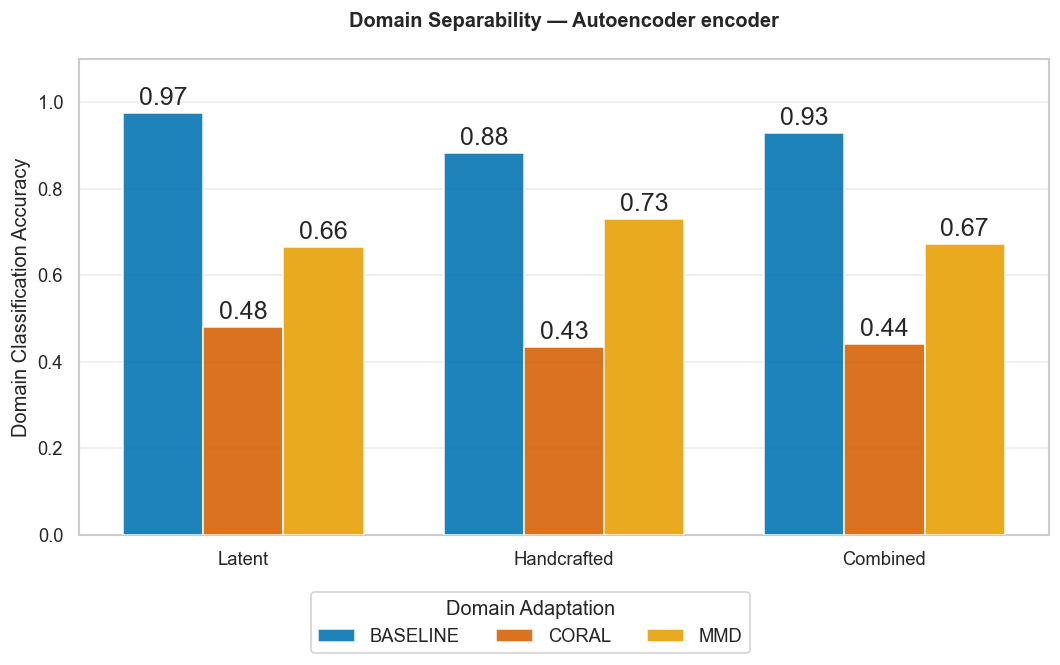

In [ ]:
ARCH_DOM    = "autoencoder"
FEAT_BLOCKS = ["Latent", "Handcrafted", "Combined"]

sub = df_domain[df_domain["Arch Mode"] == ARCH_DOM]
agg = (sub.groupby(["DA Variant", "Feature Block"])["Accuracy"]
         .agg(mean="mean", std="std").reset_index())

x, width = np.arange(len(FEAT_BLOCKS)), 0.25
offsets   = [-width, 0, width]

fig, ax = plt.subplots(figsize=(9, 5))
for j, da in enumerate(DA_VARIANTS):
    da_sub = (agg[agg["DA Variant"] == da]
              .set_index("Feature Block").reindex(FEAT_BLOCKS))
    means = da_sub["mean"].fillna(0).values
    stds  = da_sub["std"].fillna(0).values
    
    # Save the bar container to add labels
    bars = ax.bar(x + offsets[j], means, width, label=da.upper(),
           color=DA_COLORS[da], edgecolor="white", alpha=0.88, zorder=3)
    
    # Add values on top of the bars
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=15)

n_dom = int(sub["N Domains"].max()) if (not sub.empty and "N Domains" in sub.columns) else 5
ax.set_xticks(x); ax.set_xticklabels(FEAT_BLOCKS)
ax.set_ylabel("Domain Classification Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title(f"Domain Separability — Autoencoder encoder\n")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Domain Adaptation", loc="lower center", 
           bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, f"{ARCH_DOM}_domain_separability.pdf"))
plt.show()

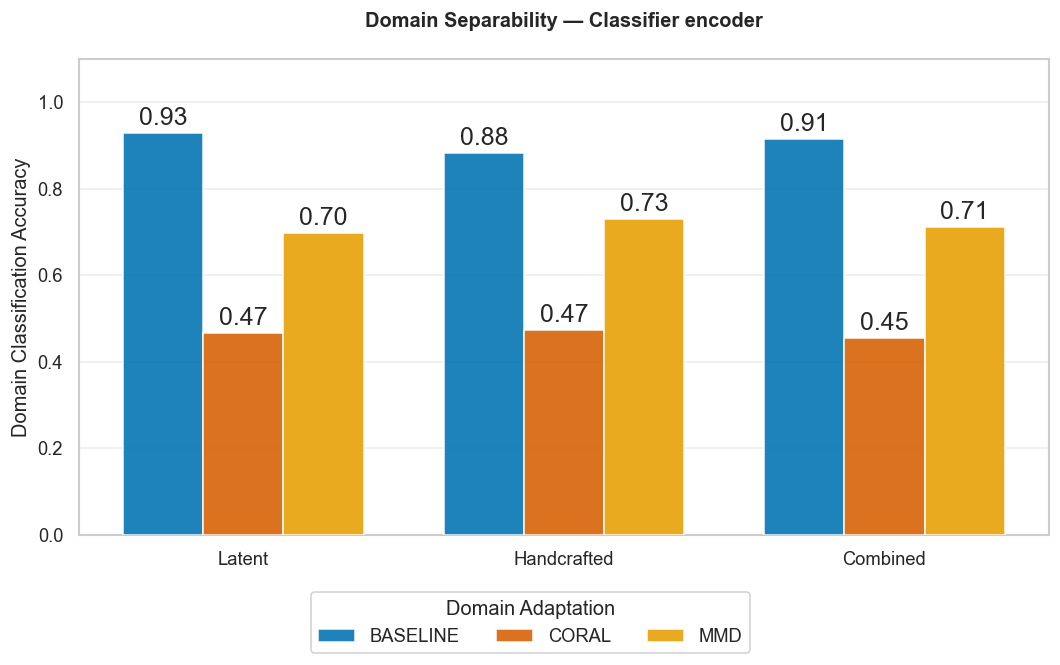

In [ ]:
ARCH_DOM    = "classifier"
FEAT_BLOCKS = ["Latent", "Handcrafted", "Combined"]

sub = df_domain[df_domain["Arch Mode"] == ARCH_DOM]
agg = (sub.groupby(["DA Variant", "Feature Block"])["Accuracy"]
         .agg(mean="mean", std="std").reset_index())

x, width = np.arange(len(FEAT_BLOCKS)), 0.25
offsets   = [-width, 0, width]

fig, ax = plt.subplots(figsize=(9, 5))
for j, da in enumerate(DA_VARIANTS):
    da_sub = (agg[agg["DA Variant"] == da]
              .set_index("Feature Block").reindex(FEAT_BLOCKS))
    means = da_sub["mean"].fillna(0).values
    stds  = da_sub["std"].fillna(0).values
    
    # Save the bar container to add labels
    bars = ax.bar(x + offsets[j], means, width, label=da.upper(),
           color=DA_COLORS[da], edgecolor="white", alpha=0.88, zorder=3)
    
    # Add values on top of the bars
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=15)

n_dom = int(sub["N Domains"].max()) if (not sub.empty and "N Domains" in sub.columns) else 5

ax.set_xticks(x); ax.set_xticklabels(FEAT_BLOCKS)
ax.set_ylabel("Domain Classification Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title(f"Domain Separability — Classifier encoder\n"
           )

# Define handles and labels before creating the legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Domain Adaptation", loc="lower center", 
           bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, f"{ARCH_DOM}_domain_separability.pdf"))
plt.show()

Best thresholds: t1=0.512  t2=0.627  t3=0.673
4-class  Balanced Acc : 0.761
4-class  Macro F1     : 0.724


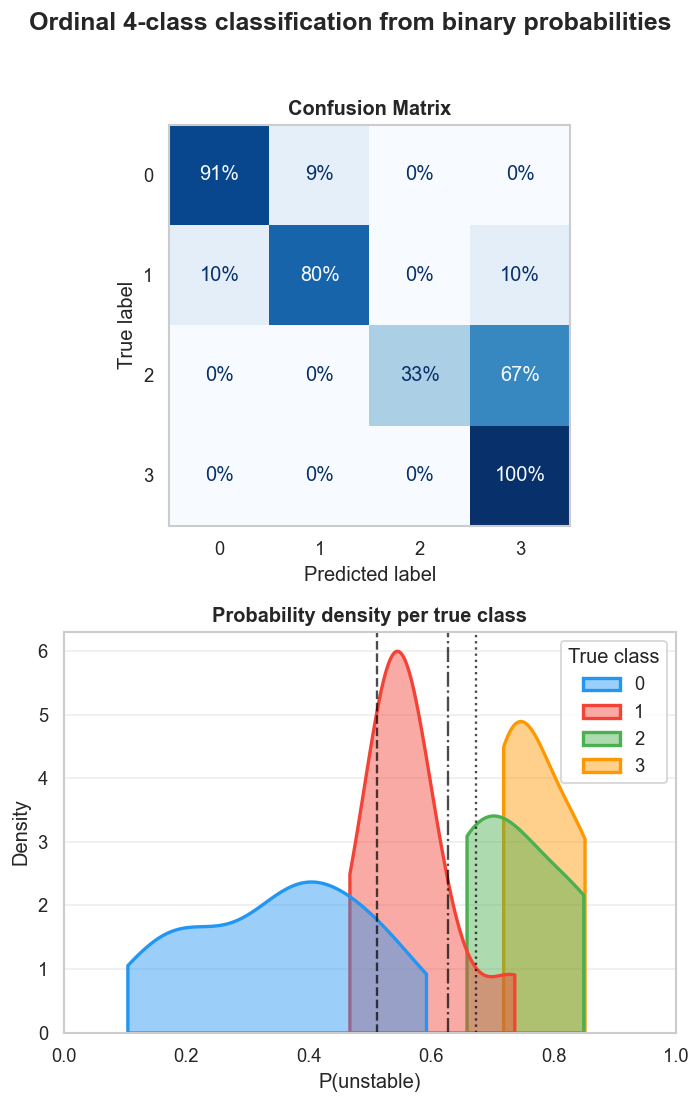

In [ ]:
from itertools import product as iproduct

SEED = 

df_coral = pd.read_excel(os.path.join(RESULTS_PATH,
               f"double_ablation_predictions_autoencoder_coral_seed{SEED}.xlsx"))

y4   = df_coral["y_true_4cls"].values.astype(int)
p_rf = df_coral["prob_RandomForest_Combined_RFE"].values


grid     = np.linspace(0.05, 0.95, 40)
best_ba  = -1.0
best_thr = (0.4, 0.6, 0.7)

for t1, t2, t3 in iproduct(grid, grid, grid):
    if not (t1 < t2 < t3):
        continue
    pred = np.where(p_rf < t1, 0,
           np.where(p_rf < t2, 1,
           np.where(p_rf < t3, 2, 3)))
    ba = balanced_accuracy_score(y4, pred)
    if ba > best_ba:
        best_ba  = ba
        best_thr = (t1, t2, t3)

t1, t2, t3 = best_thr
y4_pred = np.where(p_rf < t1, 0,
          np.where(p_rf < t2, 1,
          np.where(p_rf < t3, 2, 3)))

print(f"Best thresholds: t1={t1:.3f}  t2={t2:.3f}  t3={t3:.3f}")
print(f"4-class  Balanced Acc : {best_ba:.3f}")
print(f"4-class  Macro F1     : {f1_score(y4, y4_pred, average='macro', zero_division=0):.3f}")

CLS4_COLORS = ["#2196F3", "#F44336", "#4CAF50", "#FF9800"]   # blue · red · green · orange
CLS4_NAMES  = {0: "0", 1: "1", 2: "2", 3: "3"}

fig, axes = plt.subplots(2, 1, figsize=(6, 9))

# confusion matrix
ax = axes[0]
cm4_norm = confusion_matrix(y4, y4_pred, labels=[0, 1, 2, 3], normalize="true")
disp4 = ConfusionMatrixDisplay(cm4_norm,
                               display_labels=[CLS4_NAMES[c] for c in [0, 1, 2, 3]])
disp4.plot(ax=ax, cmap="Blues", colorbar=False,
            values_format=".0%")
ax.set_title(
    f"Confusion Matrix")
ax.grid(False)

# probability
ax = axes[1]
palette_named   = {CLS4_NAMES[c]: CLS4_COLORS[c] for c in [0, 1, 2, 3]}
hue_order_named = [CLS4_NAMES[c] for c in [0, 1, 2, 3]]
df_kde = pd.DataFrame({
    "P(unstable)": p_rf,
    "True class": [CLS4_NAMES[c] for c in y4],
})
sns.kdeplot(
    data=df_kde, x="P(unstable)", hue="True class",
    fill=True, common_norm=False, alpha=0.45, linewidth=2,
    ax=ax, palette=palette_named, hue_order=hue_order_named,
    cut=0,
)
for thr, ls in zip([t1, t2, t3], ["--", "-.", ":"]):
    ax.axvline(thr, color="black", linewidth=1.4, linestyle=ls, alpha=0.70)
ax.set_xlabel("P(unstable)")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.set_title("Probability density per true class")
if ax.get_legend() is not None:
    ax.get_legend().set_title("True class")

fig.suptitle(
    "Ordinal 4-class classification from binary probabilities",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "4cls_ordinal_ensemble.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()